# 🕵️ Fake Internship Detection System using Machine Learning

### Developed by: Sapna Rani

#### Project Objective
The objective of this project is to detect whether a job or internship posting is genuine or fraudulent using Natural Language Processing (NLP) and Machine Learning techniques.

In [233]:
# 📚 1. Import Libraries

In [234]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [235]:
# 📂 2. Load the Dataset

In [236]:
df = pd.read_csv("../data/fake_job_postings.csv")

In [237]:
# 📊 3. Dataset Overview

In [238]:
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [239]:
df.shape

(17880, 18)

In [240]:
df.columns

Index(['job_id', 'title', 'location', 'department', 'salary_range',
       'company_profile', 'description', 'requirements', 'benefits',
       'telecommuting', 'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent'],
      dtype='object')

In [241]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

In [242]:
df.isnull().sum()

job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64

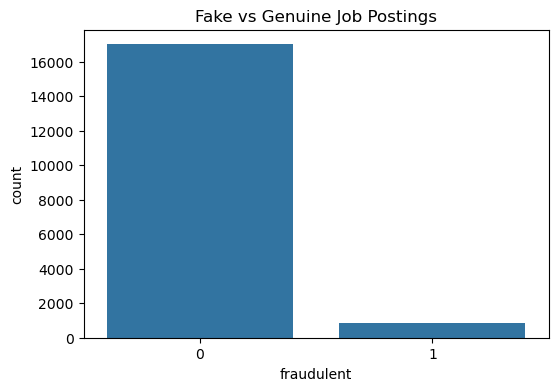

In [243]:
plt.figure(figsize=(6,4))

sns.countplot(x='fraudulent', data=df)

plt.title("Fake vs Genuine Job Postings")

plt.show()

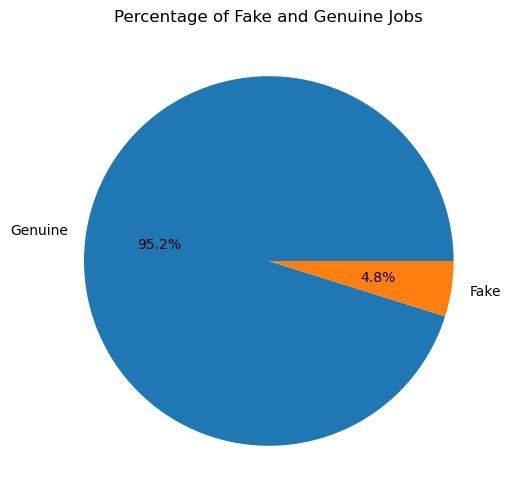

In [244]:
df["fraudulent"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    labels=["Genuine","Fake"],
    figsize=(6,6)
)
plt.title("Percentage of Fake and Genuine Jobs")
plt.ylabel("")
plt.show()

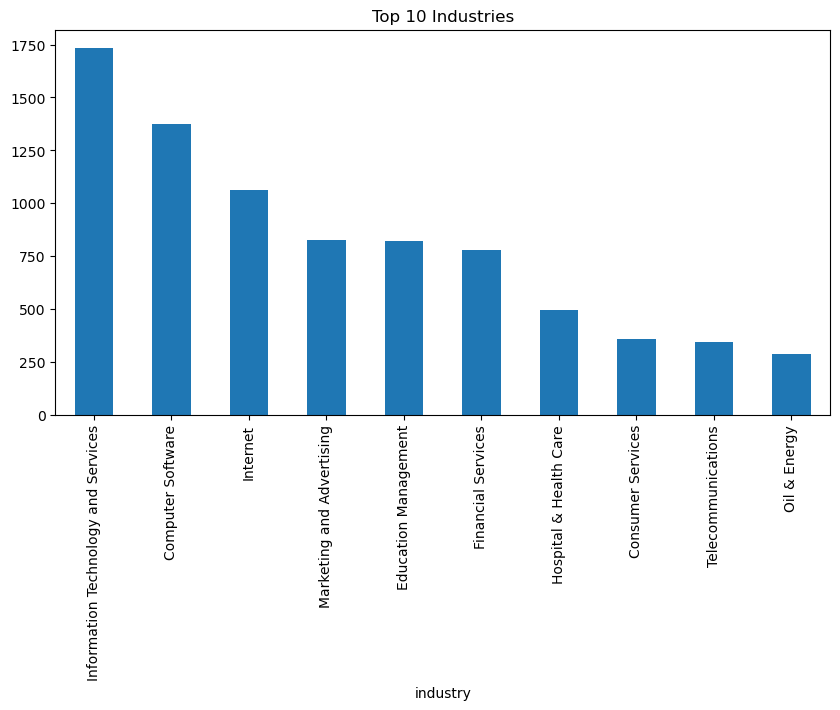

In [245]:
plt.figure(figsize=(10,5))
df["industry"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Industries")
plt.show()

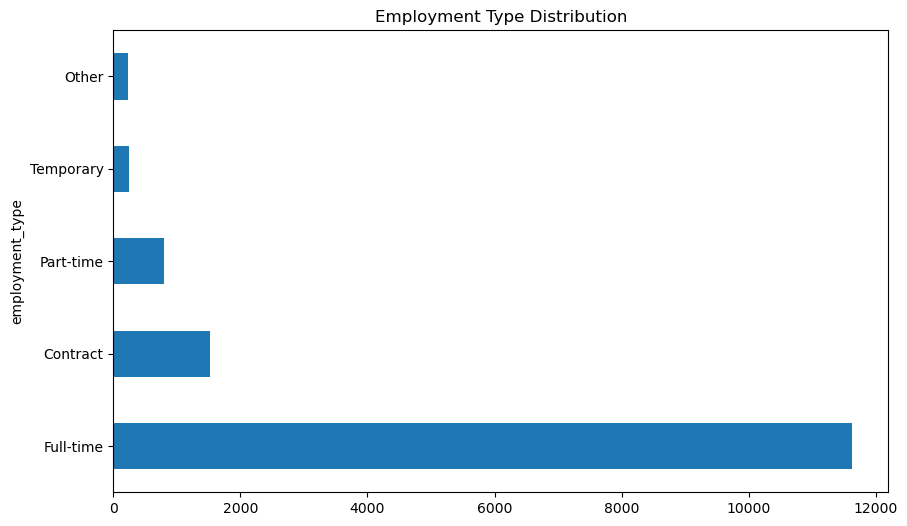

In [246]:
plt.figure(figsize=(10,6))
df["employment_type"].value_counts().plot(kind="barh")
plt.title("Employment Type Distribution")
plt.show()

In [247]:
df["description_length"] = df["description"].str.len()

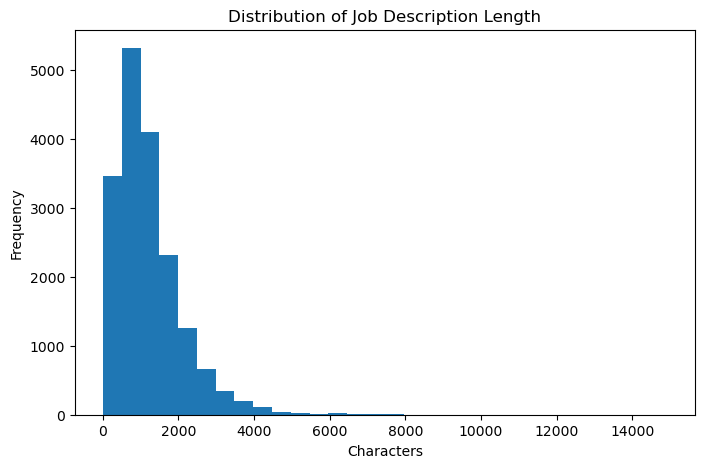

In [248]:
plt.figure(figsize=(8,5))
plt.hist(df["description_length"], bins=30)
plt.title("Distribution of Job Description Length")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.show()

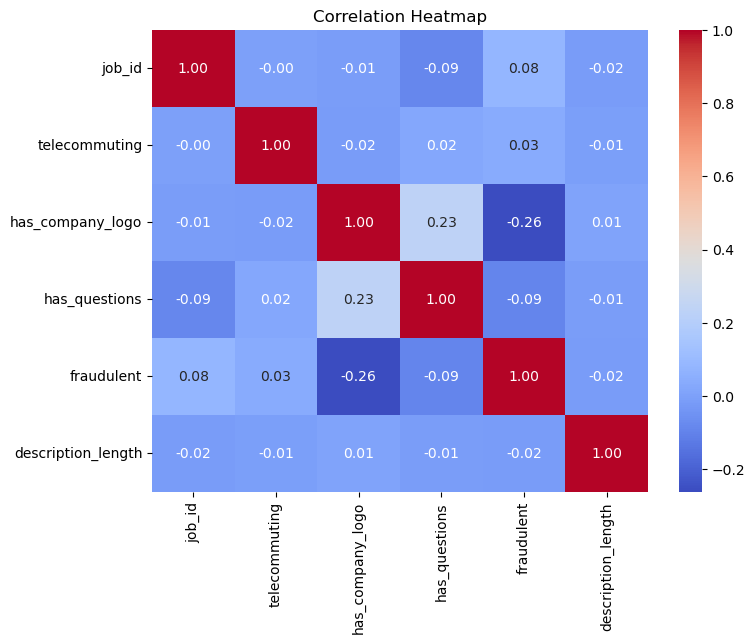

In [249]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

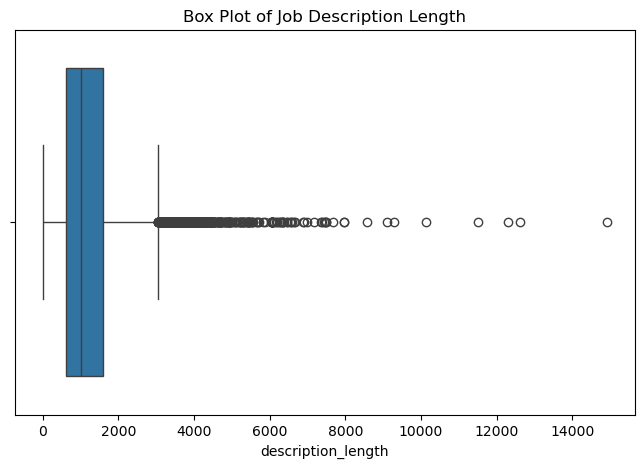

In [250]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["description_length"])
plt.title("Box Plot of Job Description Length")
plt.show()

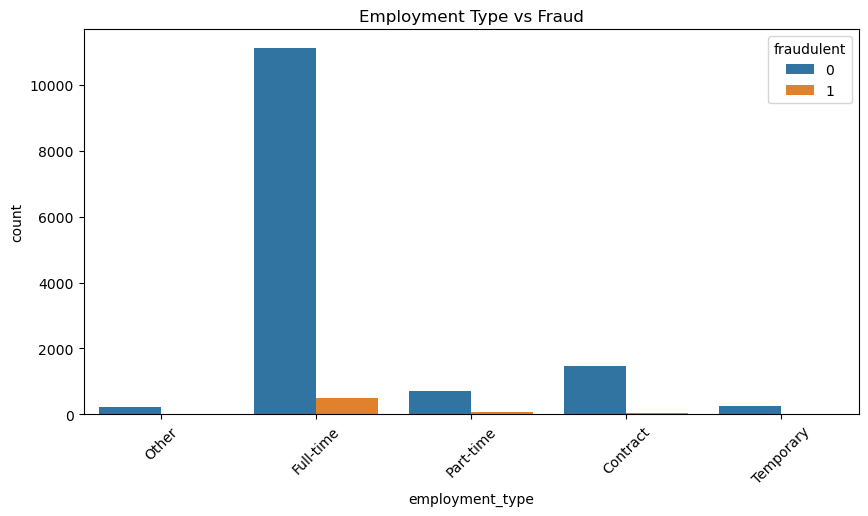

In [251]:
plt.figure(figsize=(10,5))

sns.countplot(
    x="employment_type",
    hue="fraudulent",
    data=df
)

plt.xticks(rotation=45)
plt.title("Employment Type vs Fraud")
plt.show()

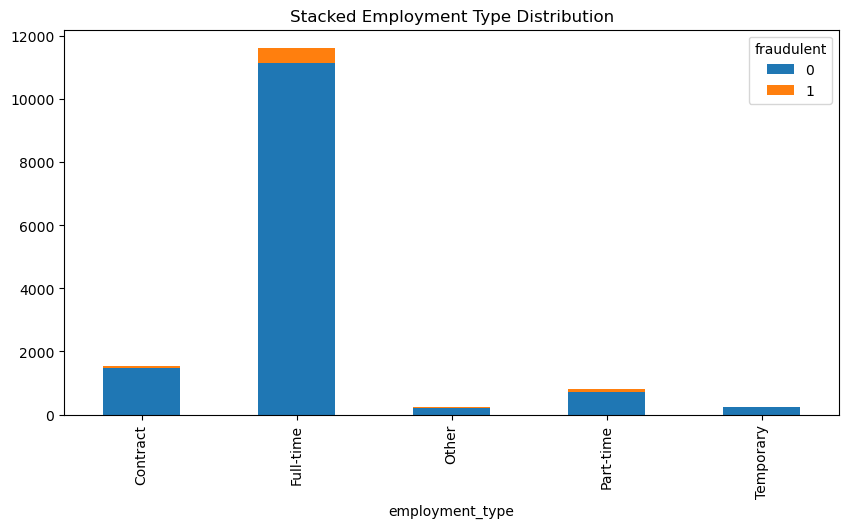

In [252]:
pd.crosstab(
    df["employment_type"],
    df["fraudulent"]
).plot(
    kind="bar",
    stacked=True,
    figsize=(10,5)
)

plt.title("Stacked Employment Type Distribution")
plt.show()

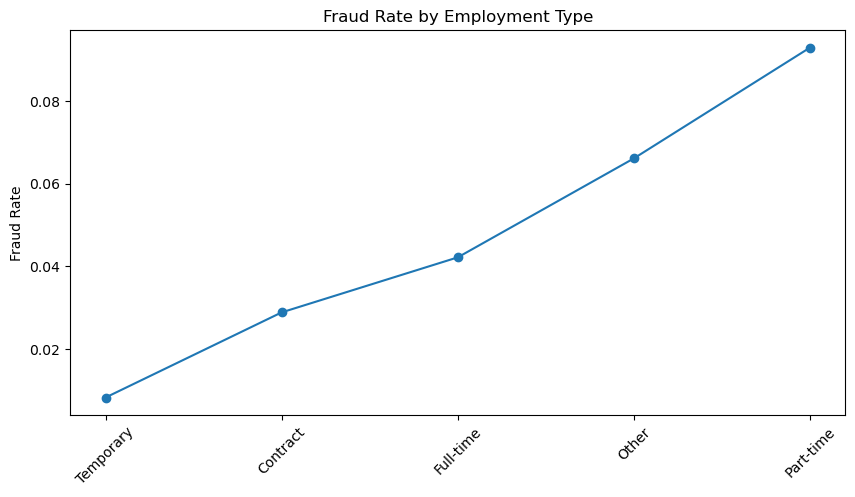

In [253]:
fraud_rate = (
    df.groupby("employment_type")["fraudulent"]
      .mean()
      .sort_values()
)

plt.figure(figsize=(10,5))
plt.plot(fraud_rate.index, fraud_rate.values, marker="o")
plt.xticks(rotation=45)
plt.title("Fraud Rate by Employment Type")
plt.ylabel("Fraud Rate")
plt.show()

In [254]:
# 🧹 4. Data Cleaning

In [255]:
# Remove unnecessary columns
df = df.drop(columns=["job_id", "salary_range"])

In [256]:
df.shape

(17880, 17)

In [257]:
df.columns

Index(['title', 'location', 'department', 'company_profile', 'description',
       'requirements', 'benefits', 'telecommuting', 'has_company_logo',
       'has_questions', 'employment_type', 'required_experience',
       'required_education', 'industry', 'function', 'fraudulent',
       'description_length'],
      dtype='object')

In [258]:
## 4.1 Check Duplicate Records

In [259]:
df.duplicated().sum()

np.int64(288)

In [260]:
df = df.drop_duplicates()

In [261]:
df.duplicated().sum()

np.int64(0)

In [262]:
## 4.2 Handle Missing Values

In [263]:
df.isnull().sum().sort_values(ascending=False)

department             11325
required_education      8009
benefits                7107
required_experience     6962
function                6363
industry                4837
employment_type         3428
company_profile         3282
requirements            2648
location                 341
description_length         1
description                1
fraudulent                 0
title                      0
has_questions              0
telecommuting              0
has_company_logo           0
dtype: int64

In [264]:
## 4.3 Handle Missing Values

In [265]:
df["description"] = df["description"].fillna("")

In [266]:
text_columns = ["company_profile","requirements","benefits","department","required_experience","required_education","industry","function","employment_type","location"]
for col in text_columns:
 df[col] = df[col].fillna("Unknown")

In [267]:
df.isnull().sum()


title                  0
location               0
department             0
company_profile        0
description            0
requirements           0
benefits               0
telecommuting          0
has_company_logo       0
has_questions          0
employment_type        0
required_experience    0
required_education     0
industry               0
function               0
fraudulent             0
description_length     1
dtype: int64

In [268]:
## 5. Feature Engineering
### Create a Combined Text Column

In [269]:
df["combined_text"] = (df["title"] + " " + df["company_profile"] + " " +df["description"] + " " +df["requirements"] + " " +df["benefits"])

In [270]:
df[["combined_text", "fraudulent"]].head()

,combined_text,fraudulent
0,"Marketing Intern We're Food52, and we've creat...",0
1,Customer Service - Cloud Video Production 90 S...,0
2,Commissioning Machinery Assistant (CMA) Valor ...,0
3,Account Executive - Washington DC Our passion ...,0
4,Bill Review Manager SpotSource Solutions LLC i...,0


In [271]:
# 🧠 6. Text Preprocessing

In [304]:
import re
import string
import nltk
from nltk.corpus import stopwords

In [305]:
stop_words = set(stopwords.words("english"))

In [306]:
def clean_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

In [307]:
df["clean_text"] = df["combined_text"].apply(clean_text)

In [308]:
df[["combined_text", "clean_text"]].head()

,combined_text,clean_text
0,"Marketing Intern We're Food52, and we've creat...",marketing intern food weve created groundbreak...
1,Customer Service - Cloud Video Production 90 S...,customer service cloud video production second...
2,Commissioning Machinery Assistant (CMA) Valor ...,commissioning machinery assistant cma valor se...
3,Account Executive - Washington DC Our passion ...,account executive washington dc passion improv...
4,Bill Review Manager SpotSource Solutions LLC i...,bill review manager spotsource solutions llc g...


In [309]:
# 🤖 7. Feature Extraction using TF-IDF

In [310]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [311]:
tfidf = TfidfVectorizer(max_features=5000)

In [312]:
X = tfidf.fit_transform(df["clean_text"])

In [313]:
y = df["fraudulent"]

In [314]:
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (17592, 5000)
Target Shape: (17592,)


In [315]:
# 🤖 8. Model Building

In [316]:
from sklearn.model_selection import train_test_split

In [317]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [318]:
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (14073, 5000)
Testing Data: (3519, 5000)


In [319]:
## 8.1 Logistic Regression Model

In [320]:
from sklearn.linear_model import LogisticRegression

In [321]:
model = LogisticRegression(max_iter=1000)

In [322]:
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [323]:
# 🤖 6. Machine Learning Pipeline

In [324]:
X = df["clean_text"]
y = df["fraudulent"]

In [325]:
from sklearn.model_selection import train_test_split

In [326]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [327]:
# 📝 7. Convert Text into Numerical Features (TF-IDF)

In [328]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [329]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

In [330]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [331]:
print("Training Shape :", X_train_tfidf.shape)
print("Testing Shape :", X_test_tfidf.shape)

Training Shape : (14073, 5000)
Testing Shape : (3519, 5000)


In [336]:
# Text Vectorization
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [337]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [338]:
# Make predictions
y_pred = model.predict(X_test_vec)

# Calculate accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("✅ Model Accuracy:", accuracy)

✅ Model Accuracy: 0.9514066496163683


In [339]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train_tfidf, y_train)

In [ ]:
# 📊 9. Model Evaluation

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [ ]:
lr_pred = lr.predict(X_test_tfidf)
nb_pred = nb.predict(X_test_tfidf)
rf_pred = rf.predict(X_test_tfidf)

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, nb_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, nb_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, nb_pred),
        f1_score(y_test, rf_pred)
    ]
})

results

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["Accuracy"])

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.ylim(0.8, 1.0)

plt.show()

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["F1 Score"])

plt.title("Model F1 Score Comparison")
plt.xlabel("Model")
plt.ylabel("F1 Score")

plt.ylim(0.8, 1.0)

plt.show()

In [ ]:
cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
print(classification_report(y_test, lr_pred))

In [ ]:
import joblib

joblib.dump(lr, "fake_job_detector.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

In [ ]:
!pip install streamlit

In [ ]:
results

In [ ]:
import joblib

joblib.dump(rf, "fake_job_detector.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

In [ ]:
import joblib

joblib.dump(rf, "fake_job_detector.pkl")

In [334]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'Fake-Job-Detection.ipynb', 'fake_job_detector.pkl', 'tfidf_vectorizer.pkl']


In [335]:
import glob

print(glob.glob("*.pkl"))

['fake_job_detector.pkl', 'tfidf_vectorizer.pkl']


In [340]:
import joblib

joblib.dump(model, "model.pkl")
joblib.dump(vectorizer, "vectorizer.pkl")

print("Model saved successfully!")

Model saved successfully!
